In [ ]:
# !pip install -U ultralytics pandas matplotlib pyyaml

from pathlib import Path
from datetime import datetime
import pandas as pd
import yaml
import torch
from ultralytics import YOLO
from IPython.display import display

print("CUDA доступна:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PROJECT_ROOT = Path(r"F:\kurs_work\runs_coursework")
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
REGISTRY_PATH = PROJECT_ROOT / "experiment_registry.csv"

DATASETS = {
    "aod4_clean": Path(r"F:\kurs_work\processed\AOD4_clean\data.yaml"),
    "aod4_aug_light": Path(r"F:\kurs_work\processed\AOD4_clean_aug_light\data.yaml"),
    "merged_clean": Path(r"F:\kurs_work\processed\merged_airborne\data.yaml"),
    "merged_aug_light": Path(r"F:\kurs_work\processed\merged_airborne_aug_light\data.yaml"),
}

CUDA доступна: True
GPU: NVIDIA GeForce GTX 1080


In [5]:
def append_registry(row):
    df_new = pd.DataFrame([row])
    if REGISTRY_PATH.exists():
        df_old = pd.read_csv(REGISTRY_PATH, sep=";")
        df = pd.concat([df_old, df_new], ignore_index=True)
    else:
        df = df_new
    df.to_csv(REGISTRY_PATH, index=False, sep=";", encoding="utf-8-sig")
    return df


def metrics_to_row(metrics, prefix="val"):
    """Достает ключевые метрики из объекта Ultralytics."""
    row = {}
    try:
        row[f"{prefix}_precision"] = float(metrics.box.mp)
        row[f"{prefix}_recall"] = float(metrics.box.mr)
        row[f"{prefix}_map50"] = float(metrics.box.map50)
        row[f"{prefix}_map50_95"] = float(metrics.box.map)
    except Exception:
        pass
    return row


def run_yolo_experiment(
    dataset_key,
    model_name="yolo11n.pt",
    epochs=30,
    imgsz=640,
    batch=10,
    workers=2,
    patience=15,
    device=0,
    pretrained=True,
    optimizer="auto",
    resume=False,
):
    data_yaml = DATASETS[dataset_key]
    if not data_yaml.exists():
        raise FileNotFoundError(f"Не найден data.yaml: {data_yaml}")

    exp_name = f"{dataset_key}_{Path(model_name).stem}_img{imgsz}_b{batch}_e{epochs}"
    model = YOLO(model_name)

    train_results = model.train(
        data=str(data_yaml),
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        workers=workers,
        patience=patience,
        project=str(PROJECT_ROOT / "yolo"),
        name=exp_name,
        device=device,
        pretrained=pretrained,
        optimizer=optimizer,
        seed=42,
        deterministic=True,
        exist_ok=True,
        resume=resume,
    )

    best_weights = PROJECT_ROOT / "yolo" / exp_name / "weights" / "best.pt"
    last_weights = PROJECT_ROOT / "yolo" / exp_name / "weights" / "last.pt"
    weights_for_eval = best_weights if best_weights.exists() else last_weights

    eval_model = YOLO(str(weights_for_eval))
    val_metrics = eval_model.val(data=str(data_yaml), split="val", imgsz=imgsz, batch=batch, device=device, project=str(PROJECT_ROOT / "yolo_val"), name=exp_name + "_val", exist_ok=True)
    test_metrics = eval_model.val(data=str(data_yaml), split="test", imgsz=imgsz, batch=batch, device=device, project=str(PROJECT_ROOT / "yolo_test"), name=exp_name + "_test", exist_ok=True)

    row = {
        "datetime": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "dataset": dataset_key,
        "model": model_name,
        "epochs": epochs,
        "imgsz": imgsz,
        "batch": batch,
        "workers": workers,
        "weights": str(weights_for_eval),
        "run_dir": str(PROJECT_ROOT / "yolo" / exp_name),
    }
    row.update(metrics_to_row(val_metrics, "val"))
    row.update(metrics_to_row(test_metrics, "test"))
    registry = append_registry(row)
    display(registry.tail(10))
    return row

In [3]:
model = YOLO(r"F:\kurs_work\runs_coursework\yolo\merged_clean_yolo11n_img640_b10_e30\weights\last.pt")
model.train(resume=True)

WARNING model 'F:\kurs_work\runs_coursework\yolo\merged_clean_yolo11n_img640_b10_e30\weights\last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.51  Python-3.13.13 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_wi

KeyboardInterrupt: 

In [ ]:
run_yolo_experiment(
    dataset_key="merged_aug_light",
    model_name=r"F:\kurs_work\runs_coursework\yolo\merged_clean_yolo11n_img640_b10_e30\weights\best.pt",
    epochs=30,
    imgsz=640,
    batch=10,
    workers=2,
    patience=5,
)

Ultralytics 8.4.51  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\kurs_work\processed\merged_airborne_aug_light\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=F:\kurs_work\runs_coursework\yolo\merged_clean_yolo11n_img640_b10_e30\weights\best.pt, momentum=0.937, mosaic=1.0, multi_scale=0

,datetime,dataset,model,epochs,imgsz,batch,workers,weights,run_dir,val_precision,val_recall,val_map50,val_map50_95,test_precision,test_recall,test_map50,test_map50_95
0,2026-05-18 14:41:33,merged_aug_light,F:\kurs_work\runs_coursework\yolo\merged_clean...,8,640,10,2,F:\kurs_work\runs_coursework\yolo\merged_aug_l...,F:\kurs_work\runs_coursework\yolo\merged_aug_l...,0.94088,0.928652,0.960321,0.650741,0.946047,0.92834,0.961404,0.671513


{'datetime': '2026-05-18 14:41:33',
 'dataset': 'merged_aug_light',
 'model': 'F:\\kurs_work\\runs_coursework\\yolo\\merged_clean_yolo11n_img640_b10_e30\\weights\\best.pt',
 'epochs': 8,
 'imgsz': 640,
 'batch': 10,
 'workers': 2,
 'weights': 'F:\\kurs_work\\runs_coursework\\yolo\\merged_aug_light_best_img640_b10_e8\\weights\\best.pt',
 'run_dir': 'F:\\kurs_work\\runs_coursework\\yolo\\merged_aug_light_best_img640_b10_e8',
 'val_precision': 0.9408802359800564,
 'val_recall': 0.9286516816398086,
 'val_map50': 0.9603206446734148,
 'val_map50_95': 0.6507405641711135,
 'test_precision': 0.9460466423438885,
 'test_recall': 0.9283400278282545,
 'test_map50': 0.9614037591369778,
 'test_map50_95': 0.6715130468060835}

In [ ]:
run_yolo_experiment(
    dataset_key="aod4_aug_light",
    model_name=r"F:\kurs_work\runs_coursework\yolo\merged_clean_yolo11n_img640_b10_e30\weights\best.pt",
    epochs=30,
    imgsz=640,
    batch=10,
    workers=2,
    patience=5,
)

Ultralytics 8.4.51  Python-3.13.13 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\kurs_work\processed\AOD4_clean_aug_light\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=F:\kurs_work\runs_coursework\yolo\merged_clean_yolo11n_img640_b10_e30\weights\best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x0000022BA43B4E00>
Traceback (most recent call last):
  File "c:\Users\Иван\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py", line 1618, in __del__
    self._shutdown_workers()
  File "c:\Users\Иван\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py", line 1576, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.20.0 ms, read: 4.71.8 MB/s, size: 25.7 KB)
val: Scanning F:\kurs_work\processed\AOD4_clean_aug_light\labels\valid.cache... 4514 images, 125 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4514/4514 701.2Mit/s 0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.00046875), 87 bias(decay=0.0)
Plotting labels to F:\kurs_work\runs_coursework\yolo\aod4_aug_light_best_img640_b10_e8\labels.jpg... 
Image sizes 640 train, 640 val
Using 2 dataloader workers
Logging results to F:\kurs_work\runs_coursework\yolo\aod4_aug_light_best_img640_b10_e8
Starting train

,datetime,dataset,model,epochs,imgsz,batch,workers,weights,run_dir,val_precision,val_recall,val_map50,val_map50_95,test_precision,test_recall,test_map50,test_map50_95
0,2026-05-18 14:41:33,merged_aug_light,F:\kurs_work\runs_coursework\yolo\merged_clean...,8,640,10,2,F:\kurs_work\runs_coursework\yolo\merged_aug_l...,F:\kurs_work\runs_coursework\yolo\merged_aug_l...,0.94088,0.928652,0.960321,0.650741,0.946047,0.928340,0.961404,0.671513
1,2026-05-18 16:12:57,aod4_aug_light,F:\kurs_work\runs_coursework\yolo\merged_clean...,8,640,10,2,F:\kurs_work\runs_coursework\yolo\aod4_aug_lig...,F:\kurs_work\runs_coursework\yolo\aod4_aug_lig...,0.93958,0.927362,0.958398,0.637899,0.937488,0.920479,0.955883,0.646181


{'datetime': '2026-05-18 16:12:57',
 'dataset': 'aod4_aug_light',
 'model': 'F:\\kurs_work\\runs_coursework\\yolo\\merged_clean_yolo11n_img640_b10_e30\\weights\\best.pt',
 'epochs': 8,
 'imgsz': 640,
 'batch': 10,
 'workers': 2,
 'weights': 'F:\\kurs_work\\runs_coursework\\yolo\\aod4_aug_light_best_img640_b10_e8\\weights\\best.pt',
 'run_dir': 'F:\\kurs_work\\runs_coursework\\yolo\\aod4_aug_light_best_img640_b10_e8',
 'val_precision': 0.9395797199160877,
 'val_recall': 0.927361989249208,
 'val_map50': 0.9583979520735961,
 'val_map50_95': 0.6378988542533512,
 'test_precision': 0.9374875716494713,
 'test_recall': 0.920478665015068,
 'test_map50': 0.9558833776537591,
 'test_map50_95': 0.6461807086443084}

In [3]:
run_yolo_experiment("aod4_clean", model_name="yolo11m.pt", epochs=8, imgsz=460, batch=4, workers=2)

Ultralytics 8.4.51  Python-3.13.13 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\kurs_work\processed\AOD4_clean\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=8, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=460, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aod4_clean_yolo11m_img460_b4_e8, nbs=64, nms=False, opset=None, optimize=False, op

,datetime,dataset,model,epochs,imgsz,batch,workers,weights,run_dir,val_precision,val_recall,val_map50,val_map50_95,test_precision,test_recall,test_map50,test_map50_95
0,2026-05-18 14:41:33,merged_aug_light,F:\kurs_work\runs_coursework\yolo\merged_clean...,8,640,10,2,F:\kurs_work\runs_coursework\yolo\merged_aug_l...,F:\kurs_work\runs_coursework\yolo\merged_aug_l...,0.940880,0.928652,0.960321,0.650741,0.946047,0.928340,0.961404,0.671513
1,2026-05-18 16:12:57,aod4_aug_light,F:\kurs_work\runs_coursework\yolo\merged_clean...,8,640,10,2,F:\kurs_work\runs_coursework\yolo\aod4_aug_lig...,F:\kurs_work\runs_coursework\yolo\aod4_aug_lig...,0.939580,0.927362,0.958398,0.637899,0.937488,0.920479,0.955883,0.646181
2,2026-05-18 20:02:18,aod4_clean,yolo11m.pt,8,460,4,2,F:\kurs_work\runs_coursework\yolo\aod4_clean_y...,F:\kurs_work\runs_coursework\yolo\aod4_clean_y...,0.872937,0.840552,0.880779,0.536985,0.872745,0.847807,0.890479,0.553343


{'datetime': '2026-05-18 20:02:18',
 'dataset': 'aod4_clean',
 'model': 'yolo11m.pt',
 'epochs': 8,
 'imgsz': 460,
 'batch': 4,
 'workers': 2,
 'weights': 'F:\\kurs_work\\runs_coursework\\yolo\\aod4_clean_yolo11m_img460_b4_e8\\weights\\best.pt',
 'run_dir': 'F:\\kurs_work\\runs_coursework\\yolo\\aod4_clean_yolo11m_img460_b4_e8',
 'val_precision': 0.8729373314893136,
 'val_recall': 0.840552434223383,
 'val_map50': 0.8807793453522434,
 'val_map50_95': 0.5369847401367591,
 'test_precision': 0.8727448931725841,
 'test_recall': 0.8478066218886412,
 'test_map50': 0.8904785201249081,
 'test_map50_95': 0.553343184784128}

In [8]:
run_yolo_experiment(
    dataset_key="aod4_aug_light",
    model_name=r"F:\kurs_work\runs_coursework\yolo\merged_clean_yolo11n_img640_b10_e30\weights\best.pt",
    epochs=30,
    imgsz=64,
    batch=600,
    workers=2,
    patience=5,
)

Ultralytics 8.4.51  Python-3.13.13 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=600, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=F:\kurs_work\processed\AOD4_clean_aug_light\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=F:\kurs_work\runs_coursework\yolo\merged_clean_yolo11n_img640_b10_e30\weights\best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

KeyboardInterrupt: 

In [ ]:

from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from ultralytics import YOLO
from IPython.display import display

ANALYSIS_DIR = PROJECT_ROOT / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def read_data_yaml(data_yaml_path):
    data_yaml_path = Path(data_yaml_path)
    with open(data_yaml_path, "r", encoding="utf-8") as f:
        data = yaml.safe_load(f)

    root = Path(data.get("path", data_yaml_path.parent))
    if not root.is_absolute():
        root = (data_yaml_path.parent / root).resolve()

    names = data.get("names", {})
    if isinstance(names, dict):
        class_names = [names[i] for i in sorted(names)]
    else:
        class_names = list(names)

    return data, root, class_names

def split_to_images(data_yaml_path, split="test"):
    data, root, class_names = read_data_yaml(data_yaml_path)
    split_value = data.get(split)

    if split_value is None:
        raise ValueError(f"В data.yaml нет split='{split}'")

    split_path = Path(split_value)
    if not split_path.is_absolute():
        split_path = root / split_path

    if split_path.is_file():
        with open(split_path, "r", encoding="utf-8") as f:
            image_paths = [Path(line.strip()) for line in f if line.strip()]
        image_paths = [p if p.is_absolute() else root / p for p in image_paths]
    else:
        image_paths = []
        for ext in IMAGE_EXTS:
            image_paths.extend(split_path.rglob(f"*{ext}"))

    image_paths = sorted([p for p in image_paths if p.exists()])
    if len(image_paths) == 0:
        raise FileNotFoundError(f"Не найдены изображения для split='{split}' по пути: {split_path}")

    return image_paths, class_names

def image_to_label_path(image_path):
    image_path = Path(image_path)
    parts = list(image_path.parts)

    lowered = [p.lower() for p in parts]
    if "images" in lowered:
        idx = lowered.index("images")
        parts[idx] = "labels"
        return Path(*parts).with_suffix(".txt")

    return image_path.parent.parent / "labels" / image_path.parent.name / f"{image_path.stem}.txt"

def yolo_xywh_to_xyxy(x, y, w, h, img_w, img_h):
    x1 = (x - w / 2) * img_w
    y1 = (y - h / 2) * img_h
    x2 = (x + w / 2) * img_w
    y2 = (y + h / 2) * img_h
    return [x1, y1, x2, y2]

def load_gt_boxes(image_path):
    image_path = Path(image_path)
    label_path = image_to_label_path(image_path)

    with Image.open(image_path) as img:
        img_w, img_h = img.size

    boxes = []
    if not label_path.exists():
        return boxes

    with open(label_path, "r", encoding="utf-8") as f:
        for line in f:
            values = line.strip().split()
            if len(values) < 5:
                continue

            cls = int(float(values[0]))
            x, y, w, h = map(float, values[1:5])
            boxes.append({
                "cls": cls,
                "box": yolo_xywh_to_xyxy(x, y, w, h, img_w, img_h)
            })

    return boxes

def box_iou(box_a, box_b):
    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter_area

    if union <= 0:
        return 0.0
    return inter_area / union

def predict_dataset(model, image_paths, imgsz=640, base_conf=0.001,device=0):
    predictions = {}

    for image_path in image_paths:
        result = model.predict(
            source=str(image_path),
            imgsz=imgsz,
            conf=base_conf,
            iou=0.7,
            device=device,
            verbose=False
        )[0]

        preds = []
        if result.boxes is not None and len(result.boxes) > 0:
            xyxy = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()
            clss = result.boxes.cls.cpu().numpy().astype(int)

            for box, conf, cls in zip(xyxy, confs, clss):
                preds.append({
                    "cls": int(cls),
                    "conf": float(conf),
                    "box": box.tolist()
                })

        predictions[str(image_path)] = preds

    return predictions

def match_predictions(gt_boxes, pred_boxes, iou_thr=0.5, class_aware=True):
    gt_used = set()
    pred_sorted = sorted(pred_boxes, key=lambda p: p["conf"], reverse=True)
    matches = []

    for pred_idx, pred in enumerate(pred_sorted):
        best_iou = 0.0
        best_gt_idx = None

        for gt_idx, gt in enumerate(gt_boxes):
            if gt_idx in gt_used:
                continue
            if class_aware and pred["cls"] != gt["cls"]:
                continue

            iou = box_iou(pred["box"], gt["box"])
            if iou >= iou_thr and iou > best_iou:
                best_iou = iou
                best_gt_idx = gt_idx

        if best_gt_idx is not None:
            gt_used.add(best_gt_idx)
            matches.append((best_gt_idx, pred, best_iou))

    tp = len(matches)
    fp = len(pred_boxes) - tp
    fn = len(gt_boxes) - tp

    return tp, fp, fn, matches

def safe_div(numerator, denominator):
    return numerator / denominator if denominator != 0 else 0.0

def get_model_rows_from_registry(max_models=None):
    if not REGISTRY_PATH.exists():
        raise FileNotFoundError(f"Не найден registry: {REGISTRY_PATH}")

    df = pd.read_csv(REGISTRY_PATH, sep=";")
    df = df.dropna(subset=["weights", "dataset"])

    df["weights_exists"] = df["weights"].apply(lambda p: Path(str(p)).exists())
    df = df[df["weights_exists"]].copy()

    if "test_map50_95" in df.columns:
        df = df.sort_values("test_map50_95", ascending=False, na_position="last")

    if max_models is not None:
        df = df.head(max_models)

    if len(df) == 0:
        raise ValueError("В experiment_registry.csv нет строк с существующими weights.")

    return df

def short_model_name(row):
    dataset = row.get("dataset", "dataset")
    model = Path(str(row.get("model", row.get("weights", "model")))).stem
    epochs = row.get("epochs", "")
    return f"{dataset}_{model}_e{epochs}"

print("Функции для анализа загружены.")

Функции для анализа загружены.


In [ ]:


def confidence_threshold_analysis(
    model_rows=None,
    split="test",
    thresholds=None,
    imgsz=640,
    base_conf=0.001,
    iou_thr=0.5,
    device=0,
    max_models=None
):
    if thresholds is None:
        thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)

    if model_rows is None:
        model_rows = get_model_rows_from_registry(max_models=max_models)

    all_rows = []

    for _, row in model_rows.iterrows():
        model_label = short_model_name(row)
        data_yaml = DATASETS[row["dataset"]]
        weights_path = Path(row["weights"])

        print(f"\nАнализ модели: {model_label}")
        print(f"weights: {weights_path}")

        image_paths, class_names = split_to_images(data_yaml, split=split)
        gt_by_image = {str(p): load_gt_boxes(p) for p in image_paths}

        model = YOLO(str(weights_path))
        pred_by_image = predict_dataset(
            model=model,
            image_paths=image_paths,
            imgsz=imgsz,
            base_conf=base_conf,
            device=device
        )

        for conf_thr in thresholds:
            total_tp = 0
            total_fp = 0
            total_fn = 0

            for image_path in image_paths:
                key = str(image_path)
                gt_boxes = gt_by_image[key]
                pred_boxes = [p for p in pred_by_image[key] if p["conf"] >= conf_thr]

                tp, fp, fn, _ = match_predictions(
                    gt_boxes=gt_boxes,
                    pred_boxes=pred_boxes,
                    iou_thr=iou_thr,
                    class_aware=True
                )

                total_tp += tp
                total_fp += fp
                total_fn += fn

            precision = safe_div(total_tp, total_tp + total_fp)
            recall = safe_div(total_tp, total_tp + total_fn)
            f1 = safe_div(2 * precision * recall, precision + recall)

            all_rows.append({
                "model": model_label,
                "dataset": row["dataset"],
                "weights": str(weights_path),
                "split": split,
                "conf_threshold": conf_thr,
                "iou_threshold": iou_thr,
                "tp": total_tp,
                "fp": total_fp,
                "fn": total_fn,
                "precision": precision,
                "recall": recall,
                "f1": f1
            })

    result_df = pd.DataFrame(all_rows)

    csv_path = ANALYSIS_DIR / f"confidence_threshold_analysis_{split}.csv"
    result_df.to_csv(csv_path, index=False, sep=";", encoding="utf-8-sig")

    display(result_df)

    plt.figure(figsize=(12, 7))
    for model_label in result_df["model"].unique():
        part = result_df[result_df["model"] == model_label]
        plt.plot(part["conf_threshold"], part["precision"], marker="o", label=f"{model_label} precision")
        plt.plot(part["conf_threshold"], part["recall"], marker="s", label=f"{model_label} recall")
        plt.plot(part["conf_threshold"], part["f1"], marker="^", label=f"{model_label} F1")

    plt.title("Confidence threshold analysis")
    plt.xlabel("Confidence threshold")
    plt.ylabel("Metric value")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plot_path = ANALYSIS_DIR / f"confidence_threshold_analysis_{split}.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()

    best_df = (
        result_df.sort_values(["model", "f1"], ascending=[True, False])
        .groupby("model")
        .head(1)
        .reset_index(drop=True)
    )

    print(f"CSV сохранен: {csv_path}")
    print(f"График сохранен: {plot_path}")
    print("\nЛучший confidence threshold по F1:")
    display(best_df[["model", "conf_threshold", "precision", "recall", "f1", "tp", "fp", "fn"]])

    return result_df, best_df

result_thresholds, best_thresholds = confidence_threshold_analysis(
    max_models=3,
    split="test",
    imgsz=640,
    device=0
)

Анализ ошибок модели: merged_aug_light_best_e8
weights: F:\kurs_work\runs_coursework\yolo\merged_aug_light_best_img640_b10_e8\weights\best.pt
confidence threshold: 0.35
IoU threshold: 0.5

Ошибки по классам. Сверху классы с худшим F1:


,class_id,class_name,gt_count,pred_count,tp,fp,fn,precision,recall,f1
1,1,bird,918,913,842,71,76,0.922234,0.917211,0.919716
3,3,helicopter,877,865,803,62,74,0.928324,0.915621,0.921929
0,0,airplane,820,837,777,60,43,0.928315,0.947561,0.937839
2,2,drone,1304,1274,1215,59,89,0.953689,0.931748,0.942591



Перепутывания классов:


,gt_class,pred_class,count
0,bird,airplane,6
3,drone,airplane,6
1,helicopter,airplane,2
2,helicopter,drone,2
5,airplane,drone,2
4,bird,drone,1
6,drone,helicopter,1


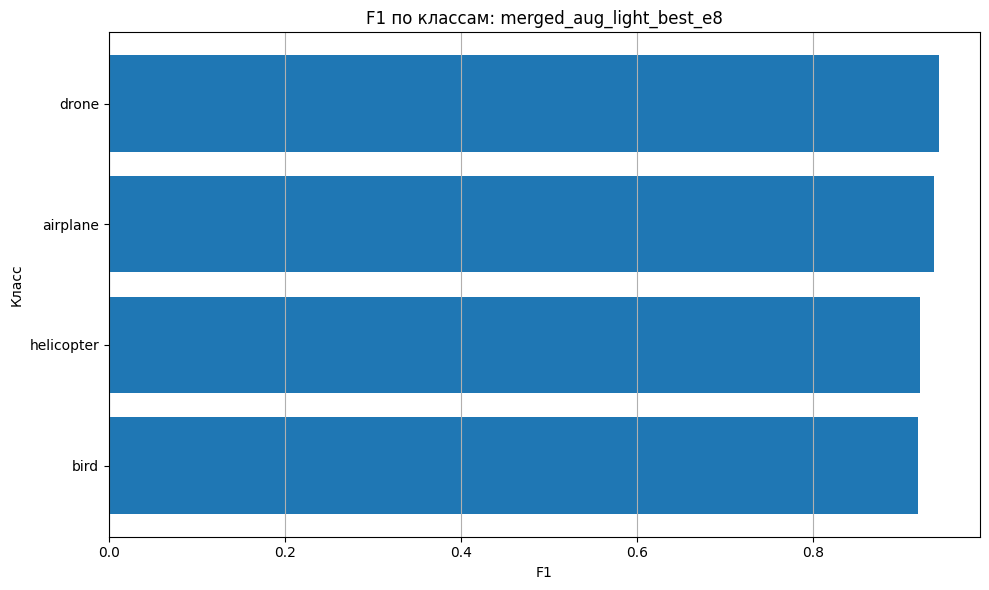

CSV по классам сохранен: F:\kurs_work\runs_coursework\analysis\class_error_analysis_merged_aug_light_best_e8_test.csv
CSV по перепутываниям сохранен: F:\kurs_work\runs_coursework\analysis\class_confusion_merged_aug_light_best_e8_test.csv
График сохранен: F:\kurs_work\runs_coursework\analysis\class_f1_merged_aug_light_best_e8_test.png


In [ ]:

def class_error_analysis(
    model_row=None,
    split="test",
    conf_thr=None,
    imgsz=640,
    iou_thr=0.5,
    device=0
):
    if model_row is None:
        rows = get_model_rows_from_registry(max_models=1)
        model_row = rows.iloc[0]

    model_label = short_model_name(model_row)
    data_yaml = DATASETS[model_row["dataset"]]
    weights_path = Path(model_row["weights"])

    if conf_thr is None:
        if "best_thresholds" in globals():
            found = best_thresholds[best_thresholds["model"] == model_label]
            conf_thr = float(found.iloc[0]["conf_threshold"]) if len(found) > 0 else 0.25
        else:
            conf_thr = 0.35

    print(f"Анализ ошибок модели: {model_label}")
    print(f"weights: {weights_path}")
    print(f"confidence threshold: {conf_thr}")
    print(f"IoU threshold: {iou_thr}")

    image_paths, class_names = split_to_images(data_yaml, split=split)
    n_classes = len(class_names)

    stats = {
        cls_id: {
            "class_id": cls_id,
            "class_name": class_names[cls_id] if cls_id < len(class_names) else str(cls_id),
            "gt_count": 0,
            "pred_count": 0,
            "tp": 0,
            "fp": 0,
            "fn": 0
        }
        for cls_id in range(n_classes)
    }

    confusion = defaultdict(int)
    false_positive_examples = []
    false_negative_examples = []
    class_confusion_examples = []

    model = YOLO(str(weights_path))
    pred_by_image = predict_dataset(
        model=model,
        image_paths=image_paths,
        imgsz=imgsz,
        base_conf=conf_thr,
        device=device
    )

    for image_path in image_paths:
        key = str(image_path)
        gt_boxes = load_gt_boxes(image_path)
        pred_boxes = [p for p in pred_by_image[key] if p["conf"] >= conf_thr]

        for gt in gt_boxes:
            if gt["cls"] in stats:
                stats[gt["cls"]]["gt_count"] += 1

        for pred in pred_boxes:
            if pred["cls"] in stats:
                stats[pred["cls"]]["pred_count"] += 1

        gt_used = set()
        pred_used = set()
        pred_sorted = sorted(list(enumerate(pred_boxes)), key=lambda item: item[1]["conf"], reverse=True)

        for pred_idx, pred in pred_sorted:
            best_iou = 0.0
            best_gt_idx = None

            for gt_idx, gt in enumerate(gt_boxes):
                if gt_idx in gt_used:
                    continue
                if pred["cls"] != gt["cls"]:
                    continue

                iou = box_iou(pred["box"], gt["box"])
                if iou >= iou_thr and iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_gt_idx is not None:
                cls_id = pred["cls"]
                stats[cls_id]["tp"] += 1
                gt_used.add(best_gt_idx)
                pred_used.add(pred_idx)

        for pred_idx, pred in enumerate(pred_boxes):
            if pred_idx not in pred_used:
                cls_id = pred["cls"]
                if cls_id in stats:
                    stats[cls_id]["fp"] += 1
                    if len(false_positive_examples) < 30:
                        false_positive_examples.append({
                            "image": key,
                            "pred_class": stats[cls_id]["class_name"],
                            "confidence": pred["conf"]
                        })

        for gt_idx, gt in enumerate(gt_boxes):
            if gt_idx not in gt_used:
                cls_id = gt["cls"]
                if cls_id in stats:
                    stats[cls_id]["fn"] += 1
                    if len(false_negative_examples) < 30:
                        false_negative_examples.append({
                            "image": key,
                            "gt_class": stats[cls_id]["class_name"]
                        })
        gt_used_any = set()
        pred_sorted_any = sorted(pred_boxes, key=lambda p: p["conf"], reverse=True)

        for pred in pred_sorted_any:
            best_iou = 0.0
            best_gt_idx = None

            for gt_idx, gt in enumerate(gt_boxes):
                if gt_idx in gt_used_any:
                    continue

                iou = box_iou(pred["box"], gt["box"])
                if iou >= iou_thr and iou > best_iou:
                    best_iou = iou
                    best_gt_idx = gt_idx

            if best_gt_idx is not None:
                gt = gt_boxes[best_gt_idx]
                gt_used_any.add(best_gt_idx)

                if pred["cls"] != gt["cls"]:
                    gt_name = class_names[gt["cls"]] if gt["cls"] < len(class_names) else str(gt["cls"])
                    pred_name = class_names[pred["cls"]] if pred["cls"] < len(class_names) else str(pred["cls"])

                    confusion[(gt_name, pred_name)] += 1

                    if len(class_confusion_examples) < 30:
                        class_confusion_examples.append({
                            "image": key,
                            "gt_class": gt_name,
                            "pred_class": pred_name,
                            "confidence": pred["conf"],
                            "iou": best_iou
                        })

    rows = []
    for cls_id, s in stats.items():
        precision = safe_div(s["tp"], s["tp"] + s["fp"])
        recall = safe_div(s["tp"], s["tp"] + s["fn"])
        f1 = safe_div(2 * precision * recall, precision + recall)

        rows.append({
            "class_id": cls_id,
            "class_name": s["class_name"],
            "gt_count": s["gt_count"],
            "pred_count": s["pred_count"],
            "tp": s["tp"],
            "fp": s["fp"],
            "fn": s["fn"],
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    class_df = pd.DataFrame(rows).sort_values("f1", ascending=True)

    confusion_rows = [
        {"gt_class": gt_name, "pred_class": pred_name, "count": count}
        for (gt_name, pred_name), count in confusion.items()
    ]
    confusion_df = pd.DataFrame(confusion_rows)
    if len(confusion_df) > 0:
        confusion_df = confusion_df.sort_values("count", ascending=False)

    safe_name = model_label.replace("\\", "_").replace("/", "_").replace(":", "_")
    class_csv = ANALYSIS_DIR / f"class_error_analysis_{safe_name}_{split}.csv"
    confusion_csv = ANALYSIS_DIR / f"class_confusion_{safe_name}_{split}.csv"

    class_df.to_csv(class_csv, index=False, sep=";", encoding="utf-8-sig")
    confusion_df.to_csv(confusion_csv, index=False, sep=";", encoding="utf-8-sig")

    print("\nОшибки по классам. Сверху классы с худшим F1:")
    display(class_df)

    if len(confusion_df) > 0:
        print("\nПерепутывания классов:")
        display(confusion_df)
    else:
        print("\nЯвных перепутываний классов по IoU-порогy не найдено.")

    plt.figure(figsize=(10, 6))
    plot_df = class_df.sort_values("f1", ascending=True)
    plt.barh(plot_df["class_name"], plot_df["f1"])
    plt.title(f"F1 по классам: {model_label}")
    plt.xlabel("F1")
    plt.ylabel("Класс")
    plt.grid(axis="x")
    plt.tight_layout()

    plot_path = ANALYSIS_DIR / f"class_f1_{safe_name}_{split}.png"
    plt.savefig(plot_path, dpi=200)
    plt.show()

    print(f"CSV по классам сохранен: {class_csv}")
    print(f"CSV по перепутываниям сохранен: {confusion_csv}")
    print(f"График сохранен: {plot_path}")

    return class_df, confusion_df, false_positive_examples, false_negative_examples, class_confusion_examples

best_model_row = get_model_rows_from_registry(max_models=1).iloc[0]

class_df, confusion_df, fp_examples, fn_examples, cls_conf_examples = class_error_analysis(
    model_row=best_model_row,
    split="test",
    conf_thr=None,
    imgsz=640,
    iou_thr=0.5,
    device=0
)

In [ ]:

from pathlib import Path
import random
import yaml
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
from ultralytics import YOLO


N_BATCHES = 10
BATCH_SIZE = 6
IMGSZ = 640
CONF_THRESHOLD = 0.35
DEVICE = 0
SEED = 42


TARGET_PART = "merged_aug_light_best_img640_b10_e30"
BATCH_VIS_DIR = PROJECT_ROOT / "batch_labels_vs_pred"
BATCH_VIS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


LABEL_COLOR = (0, 180, 0)
PRED_COLOR = (220, 40, 40)
TEXT_BG = (0, 0, 0)
TEXT_FG = (255, 255, 255)




def load_font(size=18):
    """Пытается загрузить Arial, если не получится — использует стандартный шрифт PIL."""
    for font_name in ["arial.ttf", "DejaVuSans.ttf"]:
        try:
            return ImageFont.truetype(font_name, size=size)
        except Exception:
            pass
    return ImageFont.load_default()


def read_yolo_data_yaml(data_yaml_path):
    """Читает data.yaml и возвращает словарь, корень датасета и имена классов."""
    data_yaml_path = Path(data_yaml_path)

    with open(data_yaml_path, "r", encoding="utf-8") as file:
        data = yaml.safe_load(file)

    dataset_root = Path(data.get("path", data_yaml_path.parent))
    if not dataset_root.is_absolute():
        dataset_root = (data_yaml_path.parent / dataset_root).resolve()

    names = data.get("names", {})
    if isinstance(names, dict):
        class_names = [names[index] for index in sorted(names)]
    else:
        class_names = list(names)

    return data, dataset_root, class_names


def get_split_images(data_yaml_path, split):
    """Получает список изображений для split='val' или split='test' из data.yaml."""
    data, dataset_root, class_names = read_yolo_data_yaml(data_yaml_path)

    split_value = data.get(split)
    if split_value is None:
        raise ValueError(f"В data.yaml нет поля '{split}'.")

    split_path = Path(split_value)
    if not split_path.is_absolute():
        split_path = dataset_root / split_path

    if split_path.is_file():
        image_paths = []
        with open(split_path, "r", encoding="utf-8") as file:
            for line in file:
                line = line.strip()
                if line:
                    image_path = Path(line)
                    if not image_path.is_absolute():
                        image_path = dataset_root / image_path
                    image_paths.append(image_path)
    else:
        image_paths = []
        for ext in IMAGE_EXTS:
            image_paths.extend(split_path.rglob(f"*{ext}"))
            image_paths.extend(split_path.rglob(f"*{ext.upper()}"))

    image_paths = sorted([path for path in image_paths if path.exists()])

    if len(image_paths) == 0:
        raise FileNotFoundError(f"Не найдены изображения для split='{split}' по пути: {split_path}")

    return image_paths, class_names


def image_to_label_path(image_path):
    """
    Преобразует путь изображения в путь YOLO-label.
    Поддерживает типичную структуру:
    .../images/val/name.jpg -> .../labels/val/name.txt
    """
    image_path = Path(image_path)
    parts = list(image_path.parts)
    lowered = [part.lower() for part in parts]

    if "images" in lowered:
        index = lowered.index("images")
        parts[index] = "labels"
        return Path(*parts).with_suffix(".txt")

    return image_path.parent.parent / "labels" / image_path.parent.name / f"{image_path.stem}.txt"


def yolo_xywh_to_xyxy(x_center, y_center, width, height, image_width, image_height):
    """Переводит YOLO-координаты x_center y_center width height в x1 y1 x2 y2."""
    x1 = (x_center - width / 2) * image_width
    y1 = (y_center - height / 2) * image_height
    x2 = (x_center + width / 2) * image_width
    y2 = (y_center + height / 2) * image_height
    return [x1, y1, x2, y2]


def load_yolo_labels(image_path):
    """Загружает правильные bbox из .txt-разметки YOLO."""
    image_path = Path(image_path)
    label_path = image_to_label_path(image_path)

    with Image.open(image_path) as image:
        image_width, image_height = image.size

    labels = []
    if not label_path.exists():
        return labels

    with open(label_path, "r", encoding="utf-8") as file:
        for line in file:
            values = line.strip().split()
            if len(values) < 5:
                continue

            class_id = int(float(values[0]))
            x_center, y_center, width, height = map(float, values[1:5])
            box = yolo_xywh_to_xyxy(
                x_center=x_center,
                y_center=y_center,
                width=width,
                height=height,
                image_width=image_width,
                image_height=image_height
            )

            labels.append({
                "class_id": class_id,
                "box": box
            })

    return labels


def class_name_by_id(class_names, class_id):
    """Безопасно возвращает имя класса по id."""
    if 0 <= class_id < len(class_names):
        return class_names[class_id]
    return f"class_{class_id}"


def draw_box_with_text(draw, box, text, color, font):
    """Рисует bbox и подпись над ним."""
    x1, y1, x2, y2 = [int(round(value)) for value in box]

    draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

    left, top, right, bottom = draw.textbbox((0, 0), text, font=font)
    text_width = right - left
    text_height = bottom - top

    label_x1 = x1
    label_y1 = max(0, y1 - text_height - 6)
    label_x2 = x1 + text_width + 8
    label_y2 = label_y1 + text_height + 6

    draw.rectangle([label_x1, label_y1, label_x2, label_y2], fill=color)
    draw.text((label_x1 + 4, label_y1 + 3), text, fill=TEXT_FG, font=font)


def draw_ground_truth(image_path, class_names):
    """Рисует правильную разметку labels."""
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    font = load_font(size=18)

    labels = load_yolo_labels(image_path)

    for label in labels:
        class_id = label["class_id"]
        class_name = class_name_by_id(class_names, class_id)
        text = f"LABEL: {class_name}"
        draw_box_with_text(draw, label["box"], text, LABEL_COLOR, font)

    return image


def predict_one_image(model, image_path, imgsz, conf, device):
    """Запускает YOLO-предсказание для одного изображения и возвращает список bbox."""
    result = model.predict(
        source=str(image_path),
        imgsz=imgsz,
        conf=conf,
        iou=0.7,
        device=device,
        verbose=False
    )[0]

    predictions = []
    if result.boxes is None or len(result.boxes) == 0:
        return predictions

    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)

    for box, confidence, class_id in zip(boxes, confidences, classes):
        predictions.append({
            "class_id": int(class_id),
            "confidence": float(confidence),
            "box": box.tolist()
        })

    return predictions


def draw_prediction(model, image_path, class_names, imgsz, conf, device):
    """Рисует предсказания модели."""
    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)
    font = load_font(size=18)

    predictions = predict_one_image(
        model=model,
        image_path=image_path,
        imgsz=imgsz,
        conf=conf,
        device=device
    )

    for prediction in predictions:
        class_id = prediction["class_id"]
        confidence = prediction["confidence"]
        class_name = class_name_by_id(class_names, class_id)
        text = f"PRED: {class_name} {confidence:.2f}"
        draw_box_with_text(draw, prediction["box"], text, PRED_COLOR, font)

    return image, predictions


def resize_keep_ratio(image, target_width):
    """Масштабирует изображение по ширине с сохранением пропорций."""
    width, height = image.size
    scale = target_width / width
    target_height = max(1, int(height * scale))
    return image.resize((target_width, target_height), Image.LANCZOS)


def make_side_by_side(labels_image, pred_image, title_text):
    """Склеивает labels и pred рядом."""
    target_width = 640
    labels_image = resize_keep_ratio(labels_image, target_width)
    pred_image = resize_keep_ratio(pred_image, target_width)

    title_font = load_font(size=24)
    header_height = 46
    label_header_height = 34

    width = labels_image.width + pred_image.width
    height = header_height + label_header_height + max(labels_image.height, pred_image.height)

    canvas = Image.new("RGB", (width, height), color=(245, 245, 245))
    draw = ImageDraw.Draw(canvas)

    draw.rectangle([0, 0, width, header_height], fill=(30, 30, 30))
    draw.text((12, 10), title_text, fill=TEXT_FG, font=title_font)

    small_font = load_font(size=20)
    draw.rectangle([0, header_height, labels_image.width, header_height + label_header_height], fill=LABEL_COLOR)
    draw.rectangle([labels_image.width, header_height, width, header_height + label_header_height], fill=PRED_COLOR)
    draw.text((12, header_height + 6), "LABELS / правильная разметка", fill=TEXT_FG, font=small_font)
    draw.text((labels_image.width + 12, header_height + 6), "PRED / предсказание модели", fill=TEXT_FG, font=small_font)

    y_offset = header_height + label_header_height
    canvas.paste(labels_image, (0, y_offset))
    canvas.paste(pred_image, (labels_image.width, y_offset))

    return canvas


def make_batch_grid(images, columns=2, cell_width=900):
    """Делает общую сетку из side-by-side изображений одного батча."""
    if len(images) == 0:
        raise ValueError("Нельзя создать grid: список images пуст.")

    resized = [resize_keep_ratio(image, cell_width) for image in images]

    rows = (len(resized) + columns - 1) // columns
    cell_height = max(image.height for image in resized)

    grid_width = columns * cell_width
    grid_height = rows * cell_height

    grid = Image.new("RGB", (grid_width, grid_height), color=(245, 245, 245))

    for index, image in enumerate(resized):
        row = index // columns
        column = index % columns
        x = column * cell_width
        y = row * cell_height
        grid.paste(image, (x, y))

    return grid


def labels_to_text(labels, class_names):
    """Формирует краткую строку с правильными классами изображения."""
    if len(labels) == 0:
        return "no labels"
    names = [class_name_by_id(class_names, label["class_id"]) for label in labels]
    return "; ".join(names)


def preds_to_text(predictions, class_names):
    """Формирует краткую строку с предсказанными классами изображения."""
    if len(predictions) == 0:
        return "no predictions"
    values = []
    for prediction in predictions:
        class_name = class_name_by_id(class_names, prediction["class_id"])
        confidence = prediction["confidence"]
        values.append(f"{class_name} ({confidence:.2f})")
    return "; ".join(values)


def select_model_row_from_registry(target_part=""):
    """Выбирает строку модели из experiment_registry.csv."""
    if not REGISTRY_PATH.exists():
        raise FileNotFoundError(f"Не найден файл registry: {REGISTRY_PATH}")

    registry = pd.read_csv(REGISTRY_PATH, sep=";")
    registry = registry.dropna(subset=["weights", "dataset"]).copy()
    registry["weights"] = registry["weights"].astype(str)
    registry["weights_exists"] = registry["weights"].apply(lambda value: Path(value).exists())

    registry = registry[registry["weights_exists"]].copy()
    if len(registry) == 0:
        raise ValueError("В registry нет строк с существующими weights.")

    if target_part:
        found = registry[
            registry["weights"].str.contains(target_part, case=False, regex=False)
        ].copy()

        if len(found) == 0:
            available = "\n".join(registry["weights"].head(10).tolist())
            raise ValueError(
                f"Не найдена модель, где weights содержит TARGET_PART='{target_part}'.\n"
                f"Первые доступные weights:\n{available}"
            )

        return found.iloc[0]

    if "test_map50_95" in registry.columns:
        registry = registry.sort_values("test_map50_95", ascending=False, na_position="last")

    return registry.iloc[0]



model_row = select_model_row_from_registry(TARGET_PART)

dataset_name = model_row["dataset"]
weights_path = Path(model_row["weights"])

if dataset_name not in DATASETS:
    raise KeyError(f"Датасет '{dataset_name}' есть в registry, но отсутствует в DATASETS.")

data_yaml_path = DATASETS[dataset_name]

model_stem = weights_path.parent.parent.name if weights_path.parent.name == "weights" else weights_path.stem
save_root = BATCH_VIS_DIR / f"{dataset_name}_{model_stem}_conf{CONF_THRESHOLD}"
save_root.mkdir(parents=True, exist_ok=True)

print(f"Модель: {weights_path}")
print(f"Датасет: {dataset_name}")
print(f"data.yaml: {data_yaml_path}")
print(f"Сохранение в: {save_root}")

model = YOLO(str(weights_path))
random.seed(SEED)

for split in ["val", "test"]:
    image_paths, class_names = get_split_images(data_yaml_path, split=split)

    split_dir = save_root / split
    split_dir.mkdir(parents=True, exist_ok=True)

    print(f"\nSplit: {split}")
    print(f"Всего изображений: {len(image_paths)}")

    for batch_idx in range(1, N_BATCHES + 1):
        batch_dir = split_dir / f"batch_{batch_idx:02d}"
        batch_dir.mkdir(parents=True, exist_ok=True)

        sample_size = min(BATCH_SIZE, len(image_paths))
        batch_images = random.sample(image_paths, k=sample_size)

        side_by_side_images = []
        batch_rows = []

        for image_idx, image_path in enumerate(batch_images, start=1):
            labels = load_yolo_labels(image_path)

            labels_image = draw_ground_truth(
                image_path=image_path,
                class_names=class_names
            )

            pred_image, predictions = draw_prediction(
                model=model,
                image_path=image_path,
                class_names=class_names,
                imgsz=IMGSZ,
                conf=CONF_THRESHOLD,
                device=DEVICE
            )

            title_text = f"{split} | batch {batch_idx:02d} | image {image_idx:02d} | {Path(image_path).name}"

            pair_image = make_side_by_side(
                labels_image=labels_image,
                pred_image=pred_image,
                title_text=title_text
            )

            base_name = f"{image_idx:02d}_{Path(image_path).stem}"

            labels_path = batch_dir / f"{base_name}_labels.jpg"
            pred_path = batch_dir / f"{base_name}_pred.jpg"
            pair_path = batch_dir / f"{base_name}_labels_vs_pred.jpg"

            labels_image.save(labels_path, quality=95)
            pred_image.save(pred_path, quality=95)
            pair_image.save(pair_path, quality=95)

            side_by_side_images.append(pair_image)

            batch_rows.append({
                "split": split,
                "batch": batch_idx,
                "image_index": image_idx,
                "image_path": str(image_path),
                "labels_count": len(labels),
                "pred_count": len(predictions),
                "labels": labels_to_text(labels, class_names),
                "predictions": preds_to_text(predictions, class_names),
                "labels_image": str(labels_path),
                "pred_image": str(pred_path),
                "labels_vs_pred_image": str(pair_path)
            })

        grid = make_batch_grid(
            images=side_by_side_images,
            columns=2,
            cell_width=900
        )

        grid_path = batch_dir / f"{split}_batch_{batch_idx:02d}_grid_labels_vs_pred.jpg"
        csv_path = batch_dir / f"{split}_batch_{batch_idx:02d}_labels_vs_pred.csv"

        grid.save(grid_path, quality=95)
        pd.DataFrame(batch_rows).to_csv(csv_path, index=False, sep=";", encoding="utf-8-sig")

        print(f"Сохранён {split} batch {batch_idx:02d}: {grid_path}")

print("\nГотово.")


Модель: F:\kurs_work\runs_coursework\yolo\merged_aug_light_best_img640_b10_e8\weights\best.pt
Датасет: merged_aug_light
data.yaml: F:\kurs_work\processed\merged_airborne_aug_light\data.yaml
Сохранение в: F:\kurs_work\runs_coursework\batch_labels_vs_pred\merged_aug_light_merged_aug_light_best_img640_b10_e8_conf0.35

Split: val
Всего изображений: 10548
Сохранён val batch 01: F:\kurs_work\runs_coursework\batch_labels_vs_pred\merged_aug_light_merged_aug_light_best_img640_b10_e8_conf0.35\val\batch_01\val_batch_01_grid_labels_vs_pred.jpg
Сохранён val batch 02: F:\kurs_work\runs_coursework\batch_labels_vs_pred\merged_aug_light_merged_aug_light_best_img640_b10_e8_conf0.35\val\batch_02\val_batch_02_grid_labels_vs_pred.jpg
Сохранён val batch 03: F:\kurs_work\runs_coursework\batch_labels_vs_pred\merged_aug_light_merged_aug_light_best_img640_b10_e8_conf0.35\val\batch_03\val_batch_03_grid_labels_vs_pred.jpg
Сохранён val batch 04: F:\kurs_work\runs_coursework\batch_labels_vs_pred\merged_aug_light_me

In [ ]:


from pathlib import Path
from datetime import datetime
import gc
import time
import pandas as pd
import torch
from ultralytics import YOLO
from IPython.display import display



BENCH_DATASET_KEY = "aod4_clean"     
BENCH_SPLIT = "test"                 
BENCH_IMGSZ = 640
BENCH_WORKERS = 2
BENCH_DEVICE = 0 if torch.cuda.is_available() else "cpu"
BENCH_CONF = 0.25
BENCH_IOU = 0.7


BATCH_CANDIDATES = [10, 8, 6, 4, 2, 1]


BENCH_MODELS = {
    "YOLO11n": "yolo11n.pt",
    "YOLO11m": "yolo11m.pt",
}



BENCH_DIR = PROJECT_ROOT / "speed_benchmark"
BENCH_DIR.mkdir(parents=True, exist_ok=True)


def clear_cuda_cache():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()


def count_model_parameters(model):
    """Возвращает количество параметров модели в миллионах."""
    try:
        params = sum(p.numel() for p in model.model.parameters())
        return round(params / 1_000_000, 3)
    except Exception:
        return None


def get_metric_value(metrics, attr_name):
    """Безопасно достает метрики Ultralytics."""
    try:
        return float(getattr(metrics.box, attr_name))
    except Exception:
        return None


def get_speed_value(speed_dict, key):
    """Безопасно достает скорость из metrics.speed."""
    try:
        value = speed_dict.get(key, None)
        return float(value) if value is not None else 0.0
    except Exception:
        return 0.0


def benchmark_one_model(model_label, weights_path, batch_size):
    """Запускает validation benchmark для одной модели и одного batch_size."""
    clear_cuda_cache()

    data_yaml = DATASETS[BENCH_DATASET_KEY]
    if not Path(data_yaml).exists():
        raise FileNotFoundError(f"Не найден data.yaml: {data_yaml}")

    model = YOLO(str(weights_path))
    params_m = count_model_parameters(model)

    
    try:
        model.predict(
            source=str(data_yaml),
            imgsz=BENCH_IMGSZ,
            device=BENCH_DEVICE,
            conf=BENCH_CONF,
            verbose=False,
        )
    except Exception:
    
        pass

    clear_cuda_cache()
    start_time = time.perf_counter()

    metrics = model.val(
        data=str(data_yaml),
        split=BENCH_SPLIT,
        imgsz=BENCH_IMGSZ,
        batch=batch_size,
        device=BENCH_DEVICE,
        workers=BENCH_WORKERS,
        conf=BENCH_CONF,
        iou=BENCH_IOU,
        plots=False,
        save_json=False,
        verbose=False,
        project=str(BENCH_DIR),
        name=f"{model_label}_{BENCH_DATASET_KEY}_{BENCH_SPLIT}_img{BENCH_IMGSZ}_b{batch_size}",
        exist_ok=True,
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    wall_time_sec = time.perf_counter() - start_time

    speed = getattr(metrics, "speed", {}) or {}
    preprocess_ms = get_speed_value(speed, "preprocess")
    inference_ms = get_speed_value(speed, "inference")
    loss_ms = get_speed_value(speed, "loss")
    postprocess_ms = get_speed_value(speed, "postprocess")
    total_ms = preprocess_ms + inference_ms + loss_ms + postprocess_ms

    fps = 1000.0 / total_ms if total_ms > 0 else None
    rps = fps

    row = {
        "model": model_label,
        "weights": str(weights_path),
        "dataset": BENCH_DATASET_KEY,
        "split": BENCH_SPLIT,
        "imgsz": BENCH_IMGSZ,
        "batch": batch_size,
        "device": str(BENCH_DEVICE),
        "params_million": params_m,
        "precision": get_metric_value(metrics, "mp"),
        "recall": get_metric_value(metrics, "mr"),
        "mAP50": get_metric_value(metrics, "map50"),
        "mAP50-95": get_metric_value(metrics, "map"),
        "preprocess_ms/img": preprocess_ms,
        "inference_ms/img": inference_ms,
        "postprocess_ms/img": postprocess_ms,
        "total_ms/img": total_ms,
        "FPS_images/sec": fps,
        "RPS_requests/sec": rps,
        "wall_time_sec": wall_time_sec,
    }

    del model
    clear_cuda_cache()
    return row


def benchmark_with_batch_fallback(model_label, weights_path):
    """Пробует один и тот же batch. Если не хватает памяти, уменьшает batch."""
    last_error = None

    for batch_size in BATCH_CANDIDATES:
        try:
            print(f"\nЗапуск benchmark: {model_label}, batch={batch_size}, dataset={BENCH_DATASET_KEY}, split={BENCH_SPLIT}")
            return benchmark_one_model(model_label, weights_path, batch_size)
        except RuntimeError as error:
            last_error = error
            message = str(error).lower()
            clear_cuda_cache()
            if "out of memory" in message or "cuda" in message:
                print(f"Не удалось с batch={batch_size}. Пробую batch меньше.")
                continue
            raise

    raise RuntimeError(f"Не удалось запустить benchmark для {model_label}. Последняя ошибка: {last_error}")




benchmark_rows = []

for model_label, weights_path in BENCH_MODELS.items():
    row = benchmark_with_batch_fallback(model_label, weights_path)
    benchmark_rows.append(row)

benchmark_df = pd.DataFrame(benchmark_rows)

show_df = benchmark_df.copy()
round_columns = [
    "params_million",
    "precision",
    "recall",
    "mAP50",
    "mAP50-95",
    "preprocess_ms/img",
    "inference_ms/img",
    "postprocess_ms/img",
    "total_ms/img",
    "FPS_images/sec",
    "RPS_requests/sec",
    "wall_time_sec",
]
for col in round_columns:
    if col in show_df.columns:
        show_df[col] = show_df[col].astype(float).round(3)

report_df = show_df.rename(columns={
    "model": "Модель",
    "dataset": "Датасет",
    "split": "Выборка",
    "imgsz": "Размер входа",
    "batch": "Batch",
    "device": "Устройство",
    "params_million": "Параметры, млн",
    "precision": "Precision",
    "recall": "Recall",
    "mAP50": "mAP@50",
    "mAP50-95": "mAP@50-95",
    "preprocess_ms/img": "Preprocess, мс/изобр.",
    "inference_ms/img": "Inference, мс/изобр.",
    "postprocess_ms/img": "Postprocess, мс/изобр.",
    "total_ms/img": "Итого, мс/изобр.",
    "FPS_images/sec": "FPS, изобр./с",
    "RPS_requests/sec": "RPS, запросов/с",
    "wall_time_sec": "Полное время, с",
})

report_columns = [
    "Модель",
    "Датасет",
    "Выборка",
    "Размер входа",
    "Batch",
    "Устройство",
    "Параметры, млн",
    "Precision",
    "Recall",
    "mAP@50",
    "mAP@50-95",
    "Inference, мс/изобр.",
    "Итого, мс/изобр.",
    "FPS, изобр./с",
    "RPS, запросов/с",
]
report_df = report_df[[col for col in report_columns if col in report_df.columns]]

print("\nИтоговая таблица скорости YOLO11n и YOLO11m:")
display(
    report_df.style
    .set_caption("Сравнение скорости YOLO11n и YOLO11m на одинаковой тестовой выборке")
    .format(precision=3)
    .hide(axis="index")
)


timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = BENCH_DIR / f"speed_benchmark_{BENCH_DATASET_KEY}_{BENCH_SPLIT}_{timestamp}.csv"
xlsx_path = BENCH_DIR / f"speed_benchmark_{BENCH_DATASET_KEY}_{BENCH_SPLIT}_{timestamp}.xlsx"




Запуск benchmark: YOLO11n, batch=10, dataset=aod4_clean, split=test
Ultralytics 8.4.51  Python-3.13.13 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 388.3140.8 MB/s, size: 55.2 KB)
val: Scanning F:\kurs_work\processed\AOD4_clean\labels\test.cache... 2241 images, 56 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2241/2241 723.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 225/225 15.6it/s 14.4s<0.1s
                   all       2241       3171          0          0          0          0
Speed: 0.9ms preprocess, 3.5ms inference, 0.0ms loss, 0.8ms postprocess per image

Запуск benchmark: YOLO11m, batch=10, dataset=aod4_clean, split=test
Ultralytics 8.4.51  Python-3.13.13 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1080, 8192MiB)
val: Fast image access  (ping: 0.00.0 ms, read: 500.088.7 MB/s, size: 53.2 KB)
val: Scanning F:\kurs_work\processed\AOD4_clean\label

Модель,Датасет,Выборка,Размер входа,Batch,Устройство,"Параметры, млн",Precision,Recall,mAP@50,mAP@50-95,"Inference, мс/изобр.","Итого, мс/изобр.","FPS, изобр./с","RPS, запросов/с"
YOLO11n,aod4_clean,test,640,10,0,2.624,0.000,0.000,0.000,0.000,3.541,5.182,192.977,192.977
YOLO11m,aod4_clean,test,640,10,0,20.115,0.050,0.000,0.000,0.000,18.016,19.558,51.129,51.129
